In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from scipy import stats

In [33]:
def get_data():
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    from sqlalchemy import create_engine, text

    engine = create_engine('sqlite:///Maji_Ndogo_farm_survey_small.db')
    sql_query = """
    SELECT *
    FROM geographic_features
    LEFT JOIN weather_features USING (Field_ID)
    LEFT JOIN soil_and_crop_features USING (Field_ID)
    LEFT JOIN farm_management_features USING (Field_ID)
    """
    with engine.connect() as connection:
        MD_agric_df = pd.read_sql_query(text(sql_query), connection)

    MD_agric_df.rename(columns={'Annual_yield': 'Crop_type_Temp', 'Crop_type': 'Annual_yield'}, inplace=True)
    MD_agric_df.rename(columns={'Crop_type_Temp': 'Crop_type'}, inplace=True)
    MD_agric_df['Elevation'] = MD_agric_df['Elevation'].abs()
    corrections = {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'}
    MD_agric_df['Crop_type'] = MD_agric_df['Crop_type'].apply(
        lambda crop: corrections.get(crop.strip(), crop.strip())
    )

    weather_station_mapping_df = pd.read_csv(
        'Weather_data_field_mapping.csv'
    )
    MD_agric_df = MD_agric_df.merge(weather_station_mapping_df, on='Field_ID', how='left')
    MD_agric_df = MD_agric_df.drop(columns='Unnamed: 0', errors='ignore')
    print(f'Loaded: {MD_agric_df.shape[0]} rows x {MD_agric_df.shape[1]} columns')
    return (MD_agric_df,)

In [34]:
MD_agric_df = get_data()[0]
print(MD_agric_df.shape)

Loaded: 5654 rows x 19 columns
(5654, 19)


## __Challenge 1: Sample vs. population metrics__

Our 5,654 field records are the **population** — every farm in the survey. Any subset we analyze is a **sample**. The variance formula changes depending on whether you are describing the population or estimating it from a sample: population variance divides by `n`; sample variance divides by `n-1` (Bessel's correction, which removes bias in the estimate).

### __Task__

<br>1. Calculate the population mean and variance of `Standard_yield` using `ddof=0`.
<br>2. Call `np.random.seed(42)` on the first line of the cell, then draw a random
       sample of 50 fields using the `.sample()` method.
<br>3. Calculate the sample mean and variance of that sample using `ddof=1`.
<br>4. Print all four values, formatted as shown below.

### __Expected output__

    ```
    Population mean: 0.5344
    Population variance: 0.012498
    Sample mean (n=50): 0.5305
    Sample variance (ddof=1): 0.01099.
    
    ```

In [30]:
np.random.seed(42)

# Population metrics
population_mean = MD_agric_df["Standard_yield"].mean()
population_variance = MD_agric_df["Standard_yield"].var(ddof=0)

# Random sample of 50 fields
sample = MD_agric_df.sample(n=50)

# Sample metrics
sample_mean = sample["Standard_yield"].mean()
sample_variance = sample["Standard_yield"].var(ddof=1)

# Print results
print(f"Population mean: {population_mean:.4f}")
print(f"Population variance: {population_variance:.6f}")
print(f"Sample mean (n=50): {sample_mean:.4f}")
print(f"Sample variance (ddof=1): {sample_variance:.6f}")

Population mean: 0.5344
Population variance: 0.012498
Sample mean (n=50): 0.5305
Sample variance (ddof=1): 0.010990


## __Challenge 2: The Central Limit Theorem__

A single sample mean wobbles around the true population mean. The Central Limit Theorem (CLT) says: take enough samples, and the distribution of those sample means will be approximately normal — centered on the population mean — regardless of what the original data looks like.

This is why we can use statistical tests on real-world data that is not normally distributed: the test statistics are based on sample means, not the raw data.

### __Task__

<br>1. Call `np.random.seed(42)` on the first line of the cell, then draw 1,000 samples of 30 fields each using the `.sample()` method
<br>2. Compute the mean `Standard_yield` of each sample and store results in a list called `sample_means`.
<br>3. Plot a histogram of `sample_means` with a title and axis labels.
<br>4. Print the mean of the sample means, their standard deviation, and the theoretical standard error (`population_std / sqrt(30)`).

### __Expected output__

    ```
    Mean of sample means: 0.5343
    Std of sample means: 0.0207
    Theoretical standard error: 0.0204
    
    ```

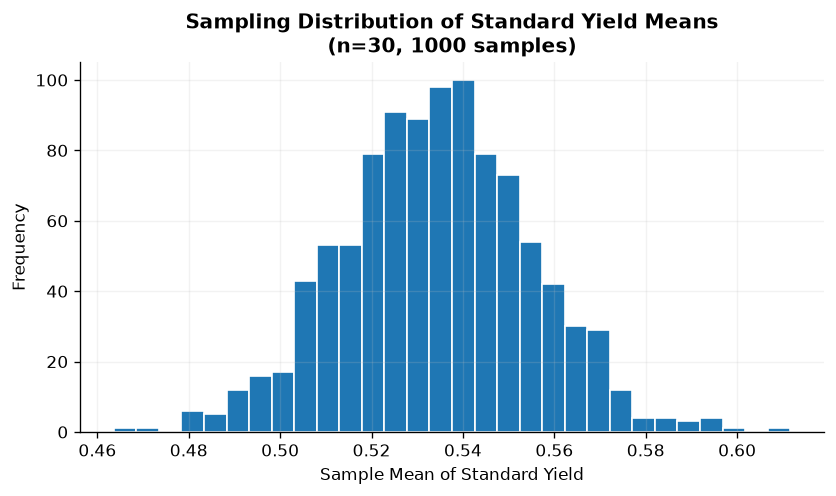

Mean of sample means: 0.5343
Std of sample means: 0.0207
Theoretical standard error: 0.0204


In [12]:
np.random.seed(42)

# Population standard deviation
population_std = MD_agric_df["Standard_yield"].std(ddof=0)

# Generate 1000 sample means
sample_means = []

for _ in range(1000):
    sample = MD_agric_df.sample(n=30)
    sample_mean = sample["Standard_yield"].mean()
    sample_means.append(sample_mean)

# Calculate statistics
mean_sample_means = np.mean(sample_means)
std_sample_means = np.std(sample_means, ddof=1)

# Theoretical standard error
theoretical_se = population_std / np.sqrt(30)

# Plot sampling distribution
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

ax.hist(
    sample_means,
    bins=30,
    edgecolor="white"
)

plt.title(
    "Sampling Distribution of Standard Yield Means\n(n=30, 1000 samples)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Sample Mean of Standard Yield", fontsize = 10)
plt.ylabel("Frequency", fontsize= 10)

plt.grid(True, alpha=0.2, color = '0.75')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# Print results
print(f"Mean of sample means: {mean_sample_means:.4f}")
print(f"Std of sample means: {std_sample_means:.4f}")
print(f"Theoretical standard error: {theoretical_se:.4f}")

__Interpretation__

The histogram represents the sampling distribution of the mean:

- The center (~0.5343) is very close to the population mean (~0.5344).
- The spread (~0.0207) is close to the theoretical standard error (~0.0204).
- This confirms the Central Limit Theorem: even if individual field yields are not normally distributed, the distribution of sample means becomes approximately normal when we take enough samples

## __Challenge 3: Confidence intervals__

A **95% confidence interval** gives a range: if we repeated this survey many times and built a CI each time, 95% of those intervals would contain the true population mean. It does **not** mean there is a 95% probability that the true mean lies in this particular interval — the true mean either is or is not in there.

SciPy syntax: `stats.t.interval(confidence, df, loc=mean, scale=sem)` — where `sem` is `stats.sem(data)` and `df` is `len(data) - 1`.

### __Task__

<br>1. Calculate the 95% CI for the mean `Standard_yield` across all 5,654 fields.
<br>2. Calculate the 95% CI for `Rainfall` in fields assigned to **weather station 0** only.
<br>3. Print both results as shown below.
<br>4. State in a comment whether the station's published mean of **1,575.95 mm** falls inside or outside the second CI.

### __Expected output__

    ```
    Mean yield: 0.5344, 95% CI: (0.5315, 0.5373)
    n: 1375, Mean rainfall: 1522.89 mm, 95% CI: (1499.83, 1545.96)
    
    ```

In [14]:
import numpy as np
from scipy import stats

# 1. Standard_yield 95% confidence interval
yield_data = MD_agric_df["Standard_yield"]

yield_mean = yield_data.mean()
yield_sem = stats.sem(yield_data)

yield_ci = stats.t.interval(
    confidence=0.95,
    df=len(yield_data)-1,
    loc=yield_mean,
    scale=yield_sem
)

# 2. Rainfall CI for Weather_station 0
station_0 = MD_agric_df[
    MD_agric_df["Weather_station"] == 0
]

rainfall_data = station_0["Rainfall"]

rainfall_mean = rainfall_data.mean()
rainfall_sem = stats.sem(rainfall_data)

rainfall_ci = stats.t.interval(
    confidence=0.95,
    df=len(rainfall_data)-1,
    loc=rainfall_mean,
    scale=rainfall_sem
)

# Print results
print(
    f"Mean yield: {yield_mean:.4f}, "
    f"95% CI: ({yield_ci[0]:.4f}, {yield_ci[1]:.4f})"
)

print(
    f"n: {len(rainfall_data)}, "
    f"Mean rainfall: {rainfall_mean:.2f} mm, "
    f"95% CI: ({rainfall_ci[0]:.2f}, {rainfall_ci[1]:.2f})"
)

Mean yield: 0.5344, 95% CI: (0.5315, 0.5373)
n: 1375, Mean rainfall: 1522.89 mm, 95% CI: (1499.83, 1545.96)


__Interpretation__

- The true population mean of Standard_yield is estimated to lie between 0.5315 and 0.5373 with 95% confidence.
- For weather station 0, the estimated rainfall mean is 1522.89 mm.
- The published value 1575.95 mm is outside the interval (1499.83, 1545.96), suggesting the published station average is significantly higher than what this sample of fields indicates.

## __Challenge 4: One-sample t-test__

The confidence interval showed the station's published rainfall mean sits outside our field data's 95% CI. But a CI only tells us the range for our mean — it does not directly test whether the station value is plausible. For that, we use a hypothesis test.

- **H₀:** The true mean rainfall near station 0 equals 1,575.95 mm — any difference is random noise.
- **H₁:** The true mean is different from 1,575.95 mm.

We reject H₀ if the p-value is below α = 0.05. A small p-value means: "if H₀ were true, the probability of seeing data this extreme by chance is less than 5%."

### __Task__

<br>1. Run `stats.ttest_1samp()` on the `Rainfall` data for fields near station 0, tested against the reference value `1575.95`. Print the t-statistic, p-value (5 decimal places), and your conclusion.
<br>2. Repeat for **average temperature** (`Ave_temps`), tested against the station reference mean of `13.4039`. Print those results too.

### __Expected output__

    **Rainfall:**
    ```
    T-statistic: -4.51238, P-value: 0.00001
    Reject H₀ — rainfall discrepancy is statistically significant.
    ```

    **Temperature:**
    ```
    T-statistic: -0.48144, P-value: 0.63028
    Fail to reject H₀ — temperature difference is consistent with random noise.
    
    ```

In [17]:
alpha = 0.05

# Filter fields near weather station 0
station_0 = MD_agric_df[
    MD_agric_df["Weather_station"] == 0
]

In [16]:
# -----------------------------
# Rainfall one-sample t-test
# -----------------------------
rainfall_test = stats.ttest_1samp(
    station_0["Rainfall"],
    popmean=1575.95
)

print("Rainfall:")
print(
    f"T-statistic: {rainfall_test.statistic:.5f}, "
    f"P-value: {rainfall_test.pvalue:.5f}"
)

if rainfall_test.pvalue < alpha:
    print("Reject H₀ — rainfall discrepancy is statistically significant.")
else:
    print("Fail to reject H₀ — rainfall difference is consistent with random noise.")

Rainfall:
T-statistic: -4.51238, P-value: 0.00001
Reject H₀ — rainfall discrepancy is statistically significant.


__Interpretation__

__Rainfall:__

- The p-value is extremely small (0.00001).
- We reject $H_0$
- The observed rainfall difference is unlikely to be caused by random sampling variation.
- The station's published rainfall average appears inconsistent with the field data.

In [18]:
# -----------------------------
# Temperature one-sample t-test
# -----------------------------
temperature_test = stats.ttest_1samp(
    station_0["Ave_temps"],
    popmean=13.4039
)

print("\nTemperature:")
print(
    f"T-statistic: {temperature_test.statistic:.5f}, "
    f"P-value: {temperature_test.pvalue:.5f}"
)

if temperature_test.pvalue < alpha:
    print("Reject H₀ — temperature difference is statistically significant.")
else:
    print("Fail to reject H₀ — temperature difference is consistent with random noise.")


Temperature:
T-statistic: -0.48144, P-value: 0.63028
Fail to reject H₀ — temperature difference is consistent with random noise.


__Interpretation__

__Temperature__

- The p-value is large (0.63028).
- We fail to reject $H_0$
- The difference between the field temperature average and the station reference value can reasonably be explained by random variation.

This demonstrates an important statistical lesson: a variable can have a statistically significant discrepancy (rainfall) while another nearby measurement (temperature) remains consistent with the reference value.

## __Challenge 5: All stations — systematic testing__

Station 0's rainfall is a problem. But what about the other four stations? Running the test one station at a time is tedious and error-prone. We need a function that systematizes the process.

### __Task__

Complete `rainfall_ttest_results(df, station_means, alpha=0.05)`. The function must:
- Accept a DataFrame, a dictionary of `{station_id: reference_rainfall_mean}`, and a significance level.
- Loop over every station in `station_means`.
- Run a one-sample t-test on the field `Rainfall` for each station against its reference mean.
- Print one line per station showing the station ID, p-value, and whether H₀ was rejected.
- Include a docstring.

  > ⚠️ Do not change the function name `rainfall_ttest_results`.

### __Expected output__

    ```
    Significant difference in Rainfall at Station 0 (P-value: 0.00001 ≤ 0.05). H₀ rejected.
    No significant difference in Rainfall at Station 1 (P-value: 0.06741 > 0.05). H₀ not rejected.
    Significant difference in Rainfall at Station 2 (P-value: 0.00542 ≤ 0.05). H₀ rejected.
    Significant difference in Rainfall at Station 3 (P-value: 0.00549 ≤ 0.05). H₀ rejected.
    Significant difference in Rainfall at Station 4 (P-value: 0.00064 ≤ 0.05). H₀ rejected.
    
    ```

In [25]:
def rainfall_ttest_results(df, station_means, alpha=0.05):

    """
    Perform one-sample t-tests comparing field rainfall
    values against published station rainfall means.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing Weather_station and Rainfall.

    station_means : dict
        Dictionary of station IDs and published rainfall means.

    alpha : float
        Significance threshold.

    """

    for station_id, reference_mean in station_means.items():

        rainfall = df.loc[
            df["Weather_station"] == station_id,
            "Rainfall"
        ]

        result = stats.ttest_1samp(
            rainfall,
            popmean=reference_mean
        )

        if result.pvalue <= alpha:
            print(
                f"Significant difference in Rainfall at Station {station_id} "
                f"(P-value: {result.pvalue:.5f} ≤ {alpha}). H₀ rejected."
            )
        else:
            print(
                f"No significant difference in Rainfall at Station {station_id} "
                f"(P-value: {result.pvalue:.5f} > {alpha}). H₀ not rejected."
            )

In [27]:
station_rainfall_means = {
        0: 1575.953750,
        1: 577.383910,
        2: 1690.955324,
        3: 905.191397,
        4: 1200.183505,
    }

rainfall_ttest_results(
    MD_agric_df,
    station_rainfall_means
)

Significant difference in Rainfall at Station 0 (P-value: 0.00001 ≤ 0.05). H₀ rejected.
No significant difference in Rainfall at Station 1 (P-value: 0.06741 > 0.05). H₀ not rejected.
Significant difference in Rainfall at Station 2 (P-value: 0.00542 ≤ 0.05). H₀ rejected.
Significant difference in Rainfall at Station 3 (P-value: 0.00549 ≤ 0.05). H₀ rejected.
Significant difference in Rainfall at Station 4 (P-value: 0.00064 ≤ 0.05). H₀ rejected.


### __Challenge 6: Type I and Type II errors — written reflection__

Every hypothesis test can be wrong in two ways:

- A **Type I error** rejects a null hypothesis that is actually true — a false alarm. α = 0.05 is the per-test probability of this happening.
- A **Type II error** fails to reject a null hypothesis that is actually false — a miss. The probability depends on sample size and effect size.

### __Task__

Answer the two questions below in the markdown cell provided.

<br>1. Our tests found statistically significant rainfall discrepancies at 4 of 5 stations. Is it plausible that all four rejections are Type I errors? Explain your reasoning using the α value.
<br>2. What would you examine next to determine whether each discrepancy is a data quality problem or a genuine physical difference between the station location and the surrounding fields?



__Answer__

### 1. __Are all four significant rainfall discrepancies likely to be Type I errors?__

It is possible that some of the rejections are Type I errors, but it is very unlikely that all four are Type I errors. With a significance level of α = 0.05, each individual test has a 5% chance of incorrectly rejecting a true null hypothesis.

If all four rejected stations were actually correct under the null hypothesis, the probability of making four Type I errors by chance would be:

$0.05^4 = 0.00000625$

or approximately **0.000625%**.

This is extremely unlikely, suggesting that the observed rainfall discrepancies are probably not just random false alarms. However, statistical significance alone does not prove the stations are incorrect; it indicates that the differences require further investigation.

### 2. __What should we examine next to determine the cause of the discrepancies?__

The next step would be to investigate whether the differences are caused by data quality issues or genuine environmental variation. I would examine:

- **Measurement methods:** Check whether weather stations and field sensors use the same instruments, calibration procedures, and recording methods.
- **Geographic differences:** Compare station locations with nearby fields, including elevation, distance, slope, and local climate conditions.
- **Spatial patterns:** Determine whether fields farther from a station show larger rainfall differences.
- **Data collection periods:** Confirm that station measurements and field observations cover the same time periods.
- **Sensor reliability:** Check for missing values, outliers, or possible equipment errors.

A significant difference could indicate inaccurate station data, but it could also reflect real microclimate differences between the weather station location and agricultural fields.

__Key statistical point:__

The reasoning should not be $p-value < 0.05$ means the station is wrong. The correct interpretation is:

> The observed rainfall difference would be unlikely if the published station mean were truly representative of the surrounding fields, so we need to investigate possible explanations.